In [10]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import numpy as np
import tensorflow as tf
import time
import sys
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Input

In [2]:
# add src/ so we can reuse the shared game utilities
sys.path.insert(0, '../src')
from connect4_model_hub import custom_objects, encode_board_for_model, legal_moves, apply_move, check_winner

In [3]:
def custom_mse_loss(y_true, y_pred):
    # only update Q-values for the column that was actually played
    # all other columns in y are set to 0 and masked out of the loss
    # same approach as professor's ddqn notebook
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)
    squared_diffs = tf.square(y_true - y_pred)
    masked_squared_diffs = squared_diffs * mask
    loss_per_sample = tf.reduce_sum(masked_squared_diffs, axis=1)
    return tf.reduce_mean(loss_per_sample)

In [4]:
def create_model():
    # same architecture as the PG network but tanh output instead of softmax
    # tanh so Q-values can be negative (loss) or positive (win)
    # input: (6,7,2) - channel 0 = my pieces, channel 1 = opponent pieces
    # output: 7 Q-values, one per column
    model = Sequential()
    model.add(Input((6, 7, 2)))
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(7, activation='tanh'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss=custom_mse_loss)
    model.call = tf.function(model.call)
    return model

In [5]:
mod = create_model()
# MUST redefine train_step every time you recreate the model - avoids TF retracing slowdown
@tf.function
def train_step(x_, y_):
    with tf.GradientTape() as tape:
        predictions = mod(x_, training=True)
        loss = custom_mse_loss(y_, predictions)
    gradients = tape.gradient(loss, mod.trainable_weights)
    mod.optimizer.apply_gradients(zip(gradients, mod.trainable_weights))
    return loss

mod.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,967 (6.23 MB)

 Trainable params: 1,632,967 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
mod_target = create_model()                    # target network - frozen copy used for Q-value estimates
mod_target.set_weights(mod.get_weights())      # start with same weights as online network

In [7]:
# load all project 1 opponent models
models_dir = '../models'
opponent_files = [
    'dean_cnn.keras',
    'dean_transformer.keras',
    'zac_cnn_best.keras',
    'zac_cnn_final.keras',
    'connor_cnn.keras',
    'archie_resnet.keras',
    'archie_transformer.keras',
]

opponent_models = []
opponent_names  = []
opponent_shapes = []

for fname in opponent_files:
    path = os.path.join(models_dir, fname)
    if os.path.exists(path):
        m = tf.keras.models.load_model(path, compile=False, safe_mode=False,
                                       custom_objects=custom_objects())
        opponent_models.append(m)
        opponent_names.append(fname.replace('.keras', ''))
        opponent_shapes.append(tuple(m.input_shape))
        print(f'loaded {fname:35s} input_shape={m.input_shape}')

print(f'\n{len(opponent_models)} opponent models loaded')

loaded dean_cnn.keras                      input_shape=(None, 6, 7, 2)
loaded dean_transformer.keras              input_shape=(None, 42, 2)
loaded zac_cnn_best.keras                  input_shape=(None, 6, 7, 2)
loaded zac_cnn_final.keras                 input_shape=(None, 6, 7, 2)
loaded connor_cnn.keras                    input_shape=(None, 6, 7, 1)
loaded archie_resnet.keras                 input_shape=(None, 6, 7, 2)
loaded archie_transformer.keras            input_shape=(None, 6, 7, 2)

7 opponent models loaded


In [8]:
def encode_for_dqn(board, player):
    # encode board as (1, 6, 7, 2) from player's perspective
    # channel 0 = my pieces, channel 1 = opponent pieces
    perspective = board * player
    channels = np.zeros((1, 6, 7, 2), dtype=np.float32)
    channels[0, :, :, 0] = (perspective == 1).astype(np.float32)
    channels[0, :, :, 1] = (perspective == -1).astype(np.float32)
    return channels


def opponent_move(opp_model, opp_shape, board, opp_player):
    # make the opponent strong: win if possible, block if necessary, else use model
    # this is adversarial training - forces DQN to learn real strategy instead of being told moves
    other = -opp_player
    legal = legal_moves(board)
    for col in legal:  # take immediate win
        if check_winner(apply_move(board, col, opp_player)) == opp_player:
            return col
    for col in legal:  # block opponent's immediate win
        if check_winner(apply_move(board, col, other)) == other:
            return col
    encoded = encode_board_for_model(board, opp_player, opp_shape)
    scores = opp_model(encoded, training=False).numpy().reshape(-1)
    masked = np.full(7, -1e18)
    for c in legal:
        masked[c] = scores[c]
    return int(np.argmax(masked))

In [14]:
# ngames     = 5000
# epsvec     = np.linspace(0.95, 0.05, ngames)  # epsilon anneals linearly over all games
# delt       = 0.95                              # discount factor
# nbatch     = 32                                # keep constant! changing this causes TF to retrace
# burn       = 500                               # wait until buffer has this many frames before SGD
# buff_max   = 50000                             # max buffer size
# reset_freq = 200                               # games between target network syncs
# snap_freq  = 500                               # games between adding DQN snapshot to opponent pool
# max_snaps  = 5                                 # max DQN snapshots in pool at once
# n_rand_init = 4                                # random moves to init each game (helps DQN find wins early)

ngames      = 50000
epsvec      = np.linspace(0.95, 0.05, ngames)
delt        = 0.95
nbatch      = 32
burn        = 200
buff_max    = 50000
reset_freq  = 200
snap_freq   = 500
max_snaps   = 5
n_rand_init = 6

buffer = {'frames': [], 'next_frames': [], 'rewards': [], 'actions': []}

snap_models = []
snap_shapes = []
snap_names  = []



In [15]:
scores = []

for game in range(ngames):
    start = time.time()
    this_ep = epsvec[game]

    if game % 200 == 199:   # freeze epsilon occasionally to see true performance + save
        this_ep = 0.0
        mod.save('../models/dqn_trained.keras')

    dqn_player = random.choice([1, -1])   # randomly go first or second
    opp_player = -dqn_player

    # pick a random opponent from base pool + any DQN snapshots
    all_opp_models = opponent_models + snap_models
    all_opp_shapes = opponent_shapes + snap_shapes
    opp_idx = np.random.choice(len(all_opp_models))
    opp_m   = all_opp_models[opp_idx]
    opp_s   = all_opp_shapes[opp_idx]

    board = np.zeros((6, 7), dtype=np.int8)
    current_player = 1

    # random init phase - play n_rand_init moves, do NOT store these in the buffer
    # this gets the board off the empty state so DQN can find early wins by chance
    for _ in range(n_rand_init):
        legal = legal_moves(board)
        if not legal:
            break
        board = apply_move(board, random.choice(legal), current_player)
        if check_winner(board) is not None:
            break
        current_player *= -1

    # store DQN's (frame, action) and push to buffer AFTER opponent replies
    # so next_frame = board on DQN's next turn, not right after DQN's move
    pending_frame  = None
    pending_action = None
    result = 0
    done = False

    while not done:
        legal = legal_moves(board)
        if not legal:  # draw
            if pending_frame is not None:
                buffer['frames'].append(pending_frame)
                buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                buffer['rewards'].append(0)
                buffer['actions'].append(pending_action)
            done = True
            break

        if current_player == dqn_player:
            if pending_frame is not None:  # push last experience now we have next_frame
                buffer['frames'].append(pending_frame)
                buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                buffer['rewards'].append(0)
                buffer['actions'].append(pending_action)

            pending_frame = encode_for_dqn(board, dqn_player)[0]
            if np.random.random() < this_ep:
                action = random.choice(legal)
            else:
                feed = encode_for_dqn(board, dqn_player)
                qvals = mod(feed, training=False)[0].numpy()
                masked = np.full(7, -1e18)
                for c in legal:
                    masked[c] = qvals[c]
                action = int(np.argmax(masked))
            pending_action = action

            board = apply_move(board, action, dqn_player)
            if check_winner(board) == dqn_player:
                buffer['frames'].append(pending_frame)
                buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                buffer['rewards'].append(1)
                buffer['actions'].append(pending_action)
                result = 1
                done = True

        else:
            action = opponent_move(opp_m, opp_s, board, opp_player)
            board = apply_move(board, action, opp_player)
            if check_winner(board) == opp_player:
                if pending_frame is not None:
                    buffer['frames'].append(pending_frame)
                    buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                    buffer['rewards'].append(-1)
                    buffer['actions'].append(pending_action)
                result = -1
                done = True

        current_player *= -1

    scores.append(result)

    # trim buffer
    if len(buffer['actions']) > buff_max:
        excess = len(buffer['actions']) - buff_max
        buffer['frames']      = buffer['frames'][excess:]
        buffer['next_frames'] = buffer['next_frames'][excess:]
        buffer['rewards']     = buffer['rewards'][excess:]
        buffer['actions']     = buffer['actions'][excess:]

    # DDQN update - only once buffer is past burn threshold
    if len(buffer['actions']) > burn:
        chosen = np.random.choice(len(buffer['actions']) - 1, nbatch, replace=False)

        current_frames = np.zeros((nbatch, 6, 7, 2), dtype=np.float32)
        next_frames    = np.zeros((nbatch, 6, 7, 2), dtype=np.float32)
        current_rewards = np.zeros(nbatch)
        current_actions = np.zeros(nbatch, dtype=int)
        for f in range(nbatch):
            current_frames[f]  = buffer['frames'][chosen[f]]
            next_frames[f]     = buffer['next_frames'][chosen[f]]
            current_rewards[f] = buffer['rewards'][chosen[f]]
            current_actions[f] = buffer['actions'][chosen[f]]

        # DDQN: online picks best next action, target scores it - reduces overestimation bias
        y_next_online = mod.predict_on_batch(next_frames)
        y_next_target = mod_target.predict_on_batch(next_frames)

        y = np.zeros((nbatch, 7))  # only the played column gets a non-zero target; rest masked by loss fn
        for grab in range(nbatch):
            a = current_actions[grab]
            r = current_rewards[grab]
            if r != 0:  # terminal (win=1 or loss=-1)
                y[grab, a] = r
            else:
                best_next = np.argmax(y_next_online[grab, :])  # online picks action
                y[grab, a] = r + delt * y_next_target[grab, best_next]  # target scores it

        x_tf = tf.convert_to_tensor(current_frames, dtype=tf.float32)
        y_tf = tf.convert_to_tensor(y, dtype=tf.float32)
        train_step(x_tf, y_tf)

    if game % reset_freq == 0 and game > 0:  # sync target network
        mod_target.set_weights(mod.get_weights())

    if game % snap_freq == 0 and game > 0:   # add DQN snapshot to opponent pool
        snap = create_model()
        snap.set_weights(mod.get_weights())
        snap_models.append(snap)
        snap_shapes.append((None, 6, 7, 2))
        snap_names.append(f'dqn_snap_game{game}')
        if len(snap_models) > max_snaps:
            snap_models.pop(0)
            snap_shapes.pop(0)
            snap_names.pop(0)
        print(f'  snapshot added at game {game} | pool={len(opponent_models)+len(snap_models)}')

    stop = time.time()
    if game % 100 == 99:
        recent = scores[-100:]
        w = recent.count(1)
        l = recent.count(-1)
        d = recent.count(0)
        print([game+1, f'W{w} L{l} D{d}', f'wr={w/100:.2f}',
               f'eps={this_ep:.3f}', f'buf={len(buffer["actions"])}', f'{stop-start:.1f}s'])

[100, 'W1 L99 D0', 'wr=0.01', 'eps=0.948', 'buf=378', '0.0s']
[200, 'W1 L99 D0', 'wr=0.01', 'eps=0.000', 'buf=729', '0.3s']
[300, 'W0 L100 D0', 'wr=0.00', 'eps=0.945', 'buf=1069', '0.0s']
[400, 'W4 L96 D0', 'wr=0.04', 'eps=0.000', 'buf=1425', '0.1s']
[500, 'W0 L100 D0', 'wr=0.00', 'eps=0.941', 'buf=1749', '0.1s']
  snapshot added at game 500 | pool=8
[600, 'W0 L100 D0', 'wr=0.00', 'eps=0.000', 'buf=2107', '0.3s']
[700, 'W0 L100 D0', 'wr=0.00', 'eps=0.937', 'buf=2467', '0.0s']
[800, 'W3 L97 D0', 'wr=0.03', 'eps=0.000', 'buf=2863', '0.2s']
[900, 'W3 L97 D0', 'wr=0.03', 'eps=0.934', 'buf=3171', '0.0s']
[1000, 'W2 L98 D0', 'wr=0.02', 'eps=0.000', 'buf=3594', '0.1s']
  snapshot added at game 1000 | pool=9
[1100, 'W3 L97 D0', 'wr=0.03', 'eps=0.930', 'buf=3981', '0.0s']
[1200, 'W1 L99 D0', 'wr=0.01', 'eps=0.000', 'buf=4356', '0.1s']
[1300, 'W1 L99 D0', 'wr=0.01', 'eps=0.927', 'buf=4771', '0.1s']
[1400, 'W1 L99 D0', 'wr=0.01', 'eps=0.000', 'buf=5160', '0.4s']
[1500, 'W0 L100 D0', 'wr=0.00', 'e

In [ ]:
mod.save('../models/dqn_trained.keras')
print('model saved')

## Training Curves

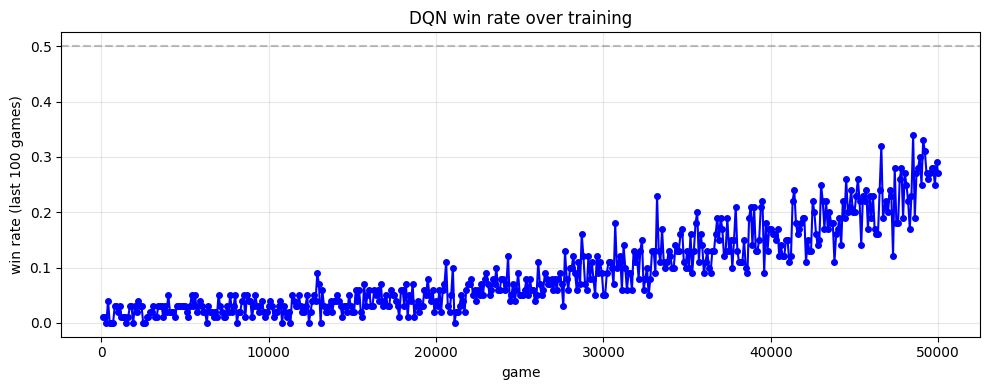

In [17]:
window = 100
win_rates  = []
game_ticks = []
for i in range(window, len(scores)+1, window):
    chunk = scores[i-window:i]
    win_rates.append(chunk.count(1) / window)
    game_ticks.append(i)

plt.figure(figsize=(10, 4))
plt.plot(game_ticks, win_rates, 'b-o', markersize=4)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('game')
plt.ylabel('win rate (last 100 games)')
plt.title('DQN win rate over training')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/dqn_training_winrate.png', dpi=150)
plt.show()

## Evaluate DQN vs Each Opponent

In [18]:
def evaluate(dqn, opp_model, opp_shape, n=100):
    # greedy eval - no epsilon, alternate who goes first each game
    wins = losses = draws = 0
    for game_idx in range(n):
        dqn_player = 1 if game_idx % 2 == 0 else -1
        opp_player = -dqn_player
        board = np.zeros((6, 7), dtype=np.int8)
        current_player = 1
        done = False
        while not done:
            legal = legal_moves(board)
            if not legal:
                draws += 1
                break
            if current_player == dqn_player:
                feed = encode_for_dqn(board, dqn_player)
                qvals = dqn(feed, training=False)[0].numpy()
                masked = np.full(7, -1e18)
                for c in legal:
                    masked[c] = qvals[c]
                col = int(np.argmax(masked))
            else:
                col = opponent_move(opp_model, opp_shape, board, opp_player)
            board = apply_move(board, col, current_player)
            winner = check_winner(board)
            if winner == dqn_player:
                wins += 1
                done = True
            elif winner is not None:
                losses += 1
                done = True
            current_player *= -1
    return wins, losses, draws


print(f'{"opponent":<25} {"W":>4} {"L":>4} {"D":>4} {"wr":>6}')
print('-' * 45)
for name, opp_m, opp_s in zip(opponent_names, opponent_models, opponent_shapes):
    w, l, d = evaluate(mod, opp_m, opp_s, n=100)
    print(f'{name:<25} {w:>4} {l:>4} {d:>4} {w/100:>6.2f}')

opponent                     W    L    D     wr
---------------------------------------------
dean_cnn                    50   50    0   0.50
dean_transformer             0   50   50   0.00
zac_cnn_best                 0   50   50   0.00
zac_cnn_final                0   50   50   0.00
connor_cnn                  50   50    0   0.50
archie_resnet                0  100    0   0.00
archie_transformer           0  100    0   0.00


## Part 5: DQN vs Policy Gradient

In [ ]:
# once we have pg_m1_trained.keras - place in ../models/ and run this cell
pg_path = '../models/pg_m1_trained.keras'

if os.path.exists(pg_path):
    pg_mod   = tf.keras.models.load_model(pg_path, compile=False, safe_mode=False,
                                          custom_objects=custom_objects())
    pg_shape = tuple(pg_mod.input_shape)
    print(f'PG agent loaded | input_shape={pg_shape}')

    # DQN vs PG head to head
    w, l, d = evaluate(mod, pg_mod, pg_shape, n=200)
    print(f'\nDQN vs PG (200 games): W={w} L={l} D={d} | DQN wr={w/200:.2f}')

    # PG vs all base opponents
    print(f'\nPG agent vs each opponent (100 games):')
    print(f'{"opponent":<25} {"W":>4} {"L":>4} {"D":>4} {"wr":>6}')
    print('-' * 45)
    for name, opp_m, opp_s in zip(opponent_names, opponent_models, opponent_shapes):
        w, l, d = evaluate(pg_mod, opp_m, opp_s, n=100)
        print(f'{name:<25} {w:>4} {l:>4} {d:>4} {w/100:>6.2f}')
else:
    print(f'pg_m1_trained.keras not found - add it to ../models/ and rerun')

In [ ]:
# comparison bar chart - only runs if PG agent is loaded
if os.path.exists(pg_path):
    dqn_rates = []
    pg_rates  = []
    for opp_m, opp_s in zip(opponent_models, opponent_shapes):
        w, l, d = evaluate(mod, opp_m, opp_s, n=100)
        dqn_rates.append(w / 100)
        w, l, d = evaluate(pg_mod, opp_m, opp_s, n=100)
        pg_rates.append(w / 100)

    x = np.arange(len(opponent_names))
    plt.figure(figsize=(11, 5))
    plt.bar(x - 0.2, dqn_rates, 0.35, label='DQN', color='steelblue')
    plt.bar(x + 0.2, pg_rates,  0.35, label='PG',  color='darkorange')
    plt.axhline(0.5, color='black', linestyle='--', alpha=0.4)
    plt.xticks(x, opponent_names, rotation=30, ha='right')
    plt.ylabel('win rate')
    plt.title('DQN vs Policy Gradient - win rate per opponent')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../data/dqn_vs_pg.png', dpi=150)
    plt.show()

    print(f'DQN avg win rate: {np.mean(dqn_rates):.2f}')
    print(f'PG  avg win rate: {np.mean(pg_rates):.2f}')